### Generate Websky 90 - 220 GHz Maps with noise or smoothing the maps

In [3]:
import time
from pixell import enmap,utils, reproject, bunch, curvedsky, enplot
from pixell import wcsutils, powspec, fft as enfft
from pixell.enmap import ndmap, samewcs, fft, ifft
from pixell.enmap import smooth_gauss
import numpy as np
import matplotlib.pyplot as plt
import importlib
from maps import white_noise
from webskymaker import create_websky_map, generate_coords
#import webskymaker
#importlib.reload(webskymaker)
coords = generate_coords()
path = "/mnt/welch/USERS/cwhitaker/maps/websky/"

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
t0 = time.time()
webskyf090map, wcs = create_websky_map(path=path, freq=90.2, noise=20, sigma=0.0000271763466773)
t1 = time.time()
print(t1 - t0)

167.80444622039795


In [2]:
websky090 = reproject.thumbnails(webskyf090map, coords[0], r = 2 * utils.degree)

NameError: name 'webskyf090map' is not defined

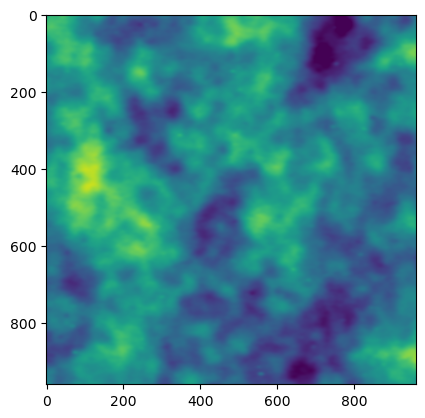

In [23]:
lims=300
plt.imshow(websky090, vmin=-lims, vmax=lims)

def smooth_gauss(emap, sigma):
	"""
    Smooth the map given as the first argument with a gaussian beam
	with the given standard deviation sigma in radians.
    """
	if np.all(sigma == 0): return emap.copy()
	f  = fft(emap)
	x2 = np.sum(emap.lmap()**2*sigma**2,0)
	if sigma >= 0: f *= np.exp(-0.5*x2)
	else:          f *= 1-np.exp(-0.5*x2)
	return enmap.enmap(ifft(f).real, emap.wcs)

In [17]:
smoothwebf = smooth_gauss(websky090, sigma = 0.000271763466773)
smoothwebf.wcs

car:{cdelt:[-0.004167,0.004167],crval:[0,0],crpix:[481.00,481.00]}

In [62]:
smoothweb = smooth_gauss(websky090, sigma = 0.0000271763466773) #ACT sigma = 0.0000271763466773

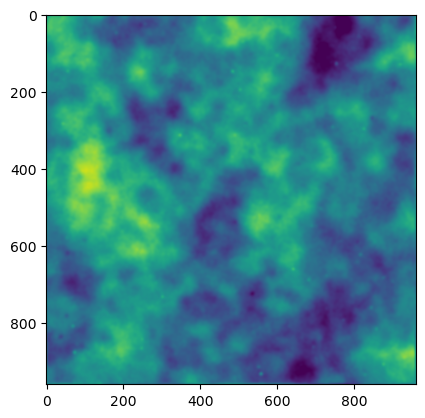

In [18]:
lims = 300
plt.imshow(smoothwebf, vmin=-lims, vmax=lims)

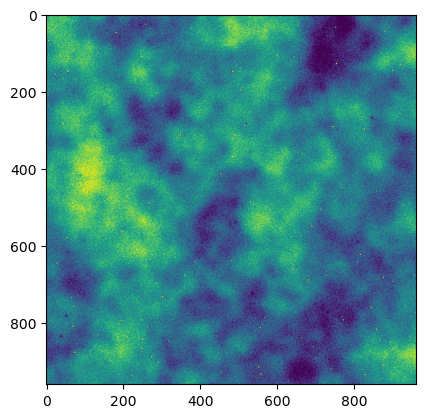

In [74]:
lims=300
plt.imshow(websky090, vmin=-lims, vmax=lims)